# VisionCare AI — YOLOv8 Eye Disease Detection
**AIAC Fresh Graduate Assessment | Task Code: AIAC-GA-2025-01**

**name:** Abdulaziz Mohammed Al-Shuieli | **Date:** 2025 | **University of Nizwa**

---
> **How to run:** Runtime → Change runtime type → **T4 GPU** → then Run All

This notebook builds a YOLOv8 classifier for 10 eye-disease classes.
We mirror the EfficientNet pipeline (EDA → balancing → baseline → k-fold → train → evaluate → XAI)
so the two models can be compared fairly.


## Step 1 — Mount Google Drive

In [1]:
# نقوم بربط جوجل درايف عشان نقدر نوصل للبيانات
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted successfully.')

Mounted at /content/drive
Drive mounted successfully.


## Step 2 — Install Libraries & Imports

In [2]:
# تثبيت المكتبات المطلوبة - Install required packages
import subprocess
subprocess.run(['pip', 'install', '-q',
                'ultralytics',     # YOLOv8 main library / مكتبة YOLOv8
                'mlflow',          # experiment tracking / تتبع التجارب
                'scikit-learn',
                'seaborn',
                'matplotlib',
                'pandas',
                'numpy',
                'tqdm',
                'opencv-python'])

# Standard library / مكتبات بايثون الأساسية
import os
import random
import shutil
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
from PIL import Image as PILImage, ImageEnhance, ImageOps

# Scikit-learn for metrics + baseline + k-fold
# سكليرن للمقاييس والنموذج الأساسي والـ k-fold
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# PyTorch + YOLO / باي تورش و يولو
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.models.yolo.classify import ClassificationTrainer

# MLflow for experiment tracking (bonus) / لتتبع التجارب
import mlflow

# Reproducibility - عشان النتائج تكون نفسها كل مرة
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU device      :', torch.cuda.get_device_name(0))
print('All imports successful.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU device      : Tesla T4
All imports successful.


## Step 3 — Project Configuration

In [3]:
# كل الإعدادات في مكان واحد - سهل تغييرها
# All project settings in one place - easy to change without hunting through the code

DATA_PATH        = Path('/content/drive/MyDrive/eys_data_project/data-2/Augmented_Dataset')
BALANCED_PATH    = Path('/content/eye_balanced')        # oversampled dataset / المجلد المتوازن
DATASET_DIR      = Path('/content/yolo_dataset')        # YOLO train/val/test layout
OUTPUT_DIR       = Path('/content/visioncare_yolo_outputs')
RUNS_DIR         = Path('/content/yolo_runs')

for d in [OUTPUT_DIR, RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE         = 224        # YOLO classification standard input
BATCH_SIZE       = 32
TARGET_PER_CLASS = 2500       # oversample every class to this number
                              # نوحد عدد الصور لكل فئة
EPOCHS           = 50         # max epochs (early stopping will cut if needed)
PATIENCE         = 15         # early stopping patience
LR0              = 0.001
LRF              = 0.01
K_FOLDS          = 5          # k-fold cross-validation (assessment requirement)
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
TEST_RATIO       = 0.15

# YOLOv8 variant - we use 'small' for a good speed/accuracy balance
# يولو الصغير - توازن جيد بين السرعة والدقة
YOLO_MODEL = 'yolov8s-cls.pt'

print('Dataset path :', DATA_PATH)
print('Output dir   :', OUTPUT_DIR)
print('YOLO model   :', YOLO_MODEL)

Dataset path : /content/drive/MyDrive/eys_data_project/data-2/Augmented_Dataset
Output dir   : /content/visioncare_yolo_outputs
YOLO model   : yolov8s-cls.pt


## Step 4 — Verify Dataset Access

In [4]:
# نتأكد إن البيانات موجودة قبل ما نبدأ
# Quick check before doing anything heavy
if not DATA_PATH.exists():
    raise FileNotFoundError('Dataset not found. Check Drive is mounted and path is correct.')

classes = sorted([d for d in os.listdir(DATA_PATH)
                  if (DATA_PATH / d).is_dir() and not d.startswith('.')])

print('Classes found ({}) :'.format(len(classes)))
for c in classes:
    n = len(list((DATA_PATH / c).glob('*.*')))
    print('  {:<45} {:>5} images'.format(c, n))

Classes found (10) :
  Central Serous Chorioretinopathy                606 images
  Diabetic Retinopathy                           3444 images
  Disc Edema                                      762 images
  Glaucoma                                       2880 images
  Healthy                                        2676 images
  Macular Scar                                   1937 images
  Myopia                                         2251 images
  Pterygium                                       102 images
  Retinal Detachment                              750 images
  Retinitis Pigmentosa                            834 images


## Step 5 — Exploratory Data Analysis (EDA)
> Assessment requires **at least 4 visualisations**. We produce 5.

                           Class  Count  Percentage
            Diabetic Retinopathy   3444       21.20
                        Glaucoma   2880       17.73
                         Healthy   2676       16.48
                          Myopia   2251       13.86
                    Macular Scar   1937       11.93
            Retinitis Pigmentosa    834        5.13
                      Disc Edema    762        4.69
              Retinal Detachment    750        4.62
Central Serous Chorioretinopathy    606        3.73
                       Pterygium    102        0.63

Total images: 16242


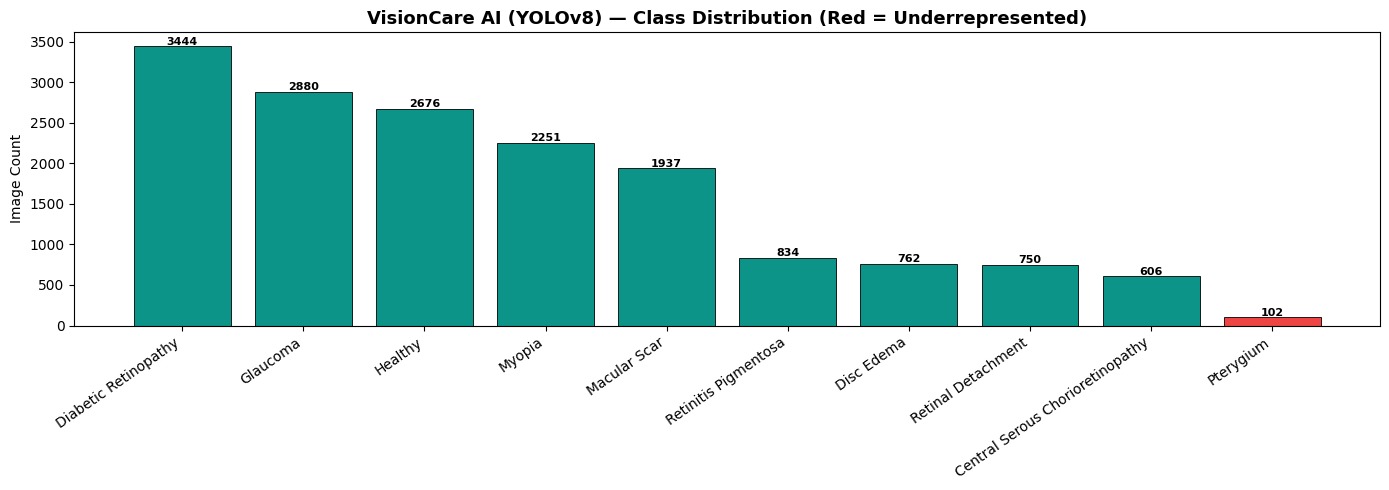

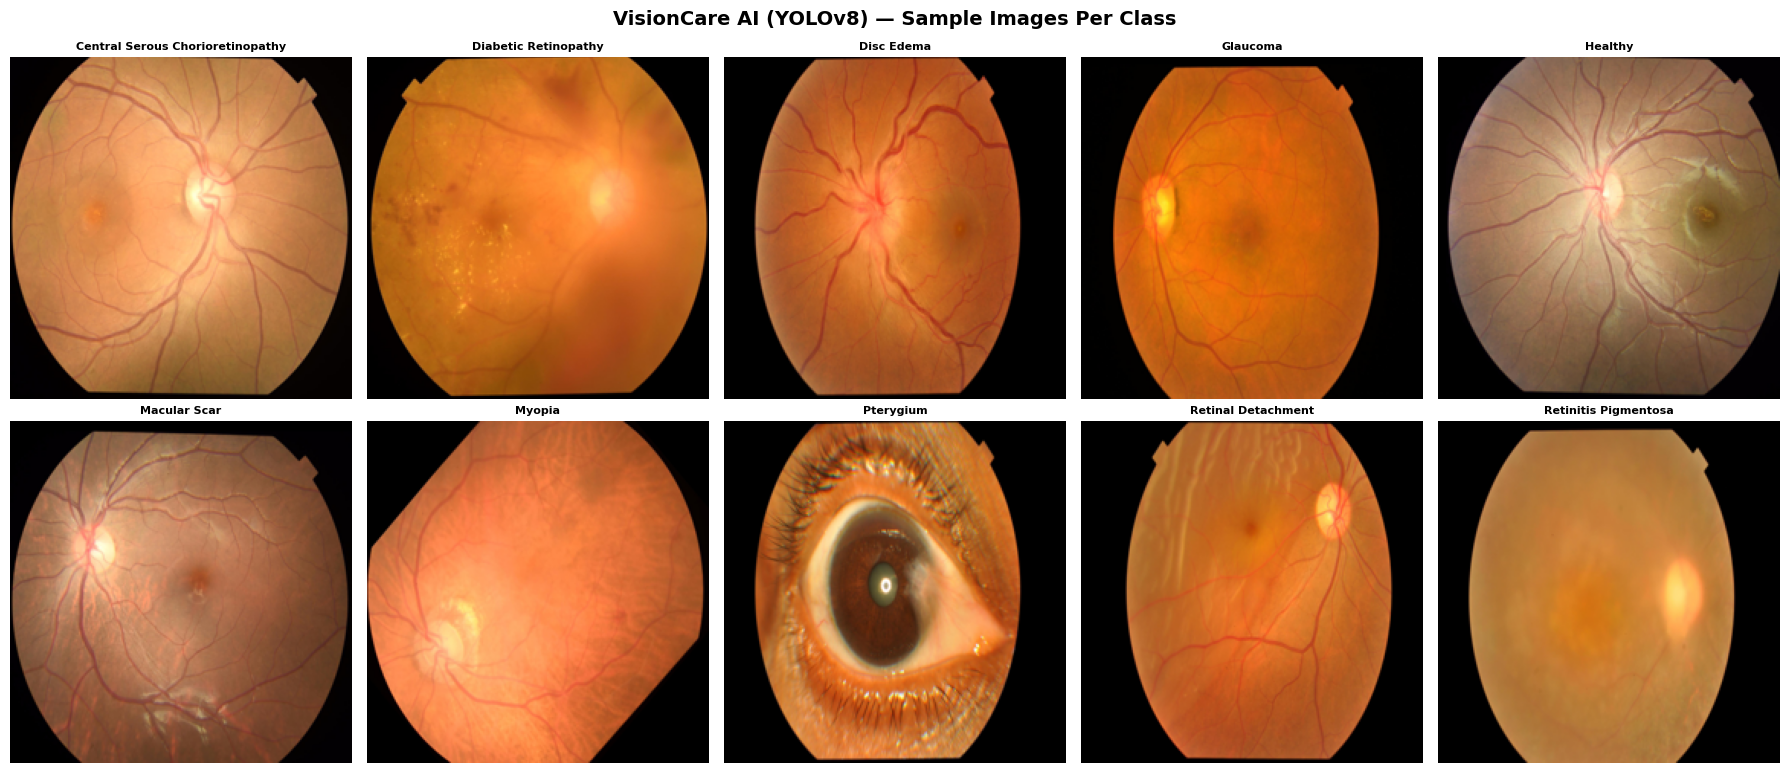

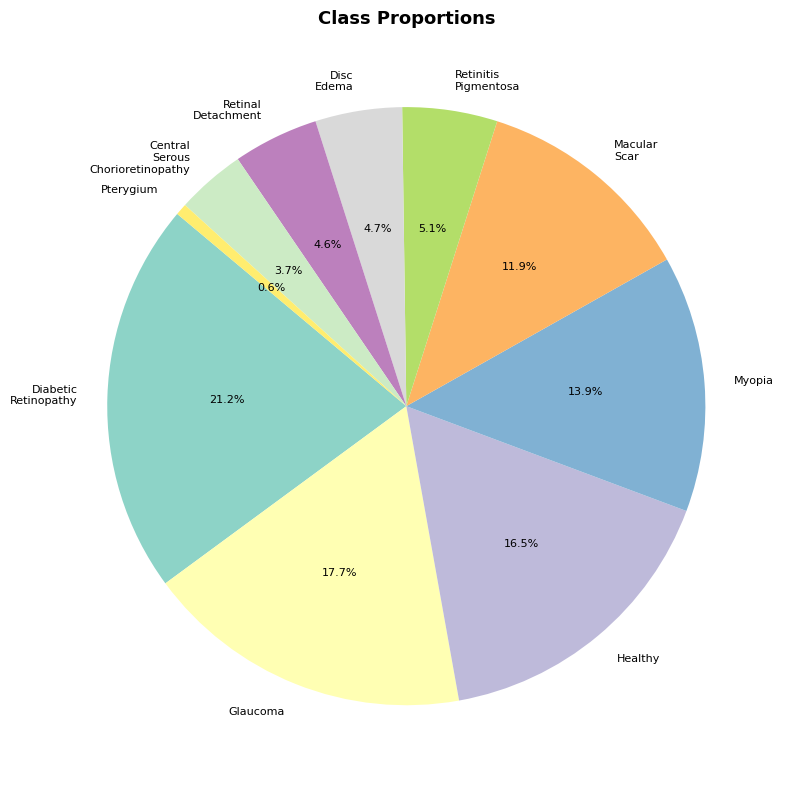

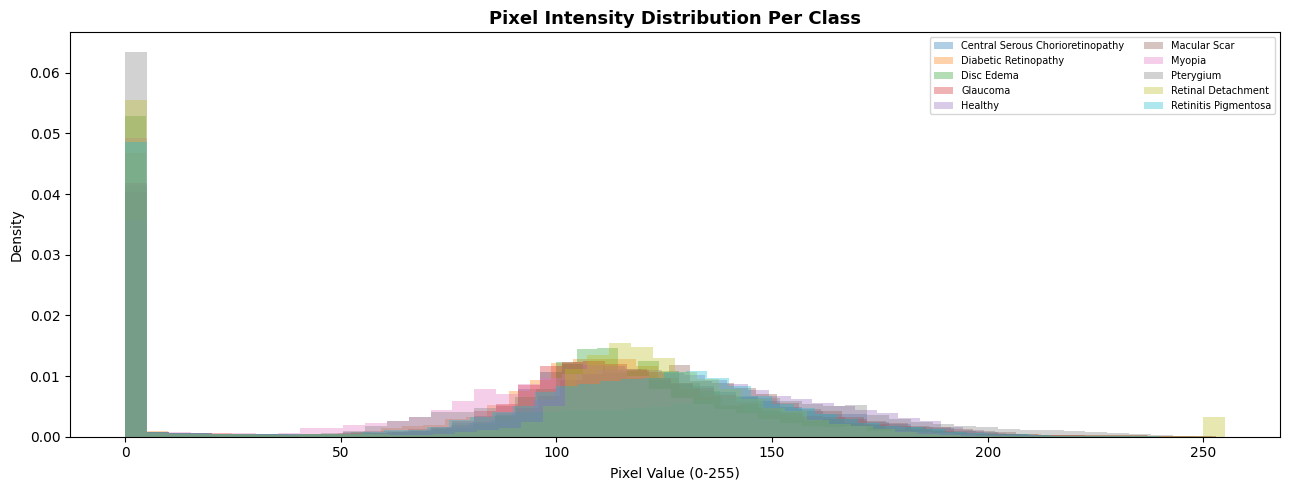

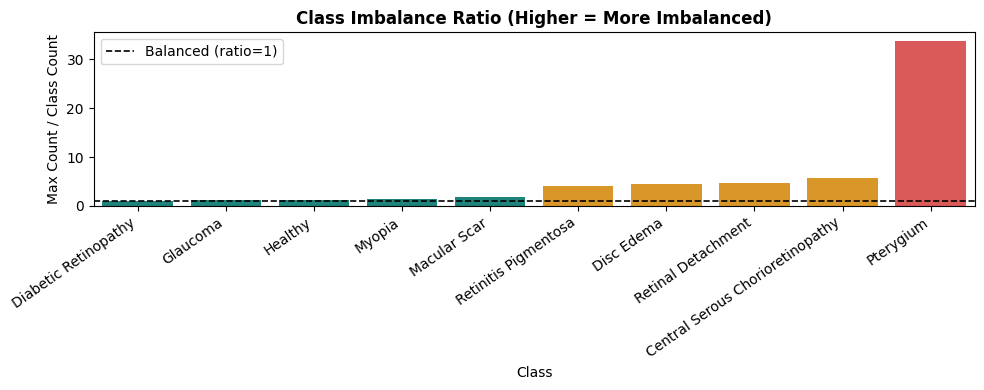

EDA complete. 5 visualisations saved.


In [5]:
# نجمع عدد الصور لكل فئة في جدول
# Collect counts using pandas for clean tabular analysis
records = []
for cls in classes:
    imgs = list((DATA_PATH / cls).glob('*.*'))
    records.append({'Class': cls, 'Count': len(imgs)})

df_dist = pd.DataFrame(records).sort_values('Count', ascending=False).reset_index(drop=True)
df_dist['Percentage'] = (df_dist['Count'] / df_dist['Count'].sum() * 100).round(2)
print(df_dist.to_string(index=False))
print('\nTotal images:', df_dist['Count'].sum())

# ── VIS 1: Class Distribution Bar Chart ──────────────────────────────
# الرسم الأول: توزيع الفئات
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#EF4444' if c == 'Pterygium' else '#0D9488' for c in df_dist['Class']]
bars = ax.bar(df_dist['Class'], df_dist['Count'], color=colors, edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, df_dist['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontsize=8, fontweight='bold')
ax.set_title('VisionCare AI (YOLOv8) — Class Distribution (Red = Underrepresented)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Image Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIS 2: Sample Images Grid ─────────────────────────────────────────
# الرسم الثاني: عينة من الصور لكل فئة
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('VisionCare AI (YOLOv8) — Sample Images Per Class', fontsize=14, fontweight='bold')
for i, cls in enumerate(classes):
    imgs = list((DATA_PATH / cls).glob('*.jpg')) + list((DATA_PATH / cls).glob('*.png'))
    if imgs:
        img = PILImage.open(random.choice(imgs)).resize((224, 224))
        axes.flat[i].imshow(img)
        axes.flat[i].set_title(cls, fontsize=8, fontweight='bold')
    axes.flat[i].axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_2_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIS 3: Pie Chart ──────────────────────────────────────────────────
# الرسم الثالث: نسبة كل فئة
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(df_dist['Count'], labels=[c.replace(' ', '\n') for c in df_dist['Class']],
       autopct='%1.1f%%', startangle=140,
       colors=plt.cm.Set3(np.linspace(0, 1, len(df_dist))),
       textprops={'fontsize': 8})
ax.set_title('Class Proportions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_3_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIS 4: Pixel Intensity Distribution ──────────────────────────────
# الرسم الرابع: توزيع شدة البكسلات
fig, ax = plt.subplots(figsize=(13, 5))
for cls in classes:
    imgs = list((DATA_PATH / cls).glob('*.jpg'))
    if not imgs: continue
    sample = random.sample(imgs, min(40, len(imgs)))
    px = []
    for p in sample:
        px.extend(np.array(PILImage.open(p).resize((64,64)).convert('L')).flatten().tolist())
    ax.hist(px, bins=50, alpha=0.35, label=cls, density=True)
ax.set_title('Pixel Intensity Distribution Per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Pixel Value (0-255)')
ax.set_ylabel('Density')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_4_pixel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIS 5: Imbalance ratio heatmap ───────────────────────────────────
# الرسم الخامس: نسبة عدم التوازن
df_ratio = df_dist.copy()
df_ratio['Imbalance Ratio'] = (df_ratio['Count'].max() / df_ratio['Count']).round(1)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_ratio, x='Class', y='Imbalance Ratio',
            palette=['#EF4444' if r > 10 else '#F59E0B' if r > 3 else '#0D9488'
                     for r in df_ratio['Imbalance Ratio']], ax=ax)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.2, label='Balanced (ratio=1)')
ax.set_title('Class Imbalance Ratio (Higher = More Imbalanced)', fontsize=12, fontweight='bold')
ax.set_ylabel('Max Count / Class Count')
plt.xticks(rotation=35, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_5_imbalance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete. 5 visualisations saved.')

## Step 6 — Balance Dataset (Oversampling)
> Pterygium has very few images. Without balancing, the model just predicts the majority class.
> We oversample every class to 2,500 images using augmentation.

In [6]:
# دالة بسيطة لعمل تعديلات عشوائية على الصورة (تدوير، انعكاس، إلخ)
# Simple augmentation function - random transformations to make new images
def augment_image(img):
    # Random horizontal flip
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    # Random vertical flip
    if random.random() > 0.5:
        img = ImageOps.flip(img)
    # Random rotation between -30 and +30 degrees
    img = img.rotate(random.uniform(-30, 30), resample=PILImage.BILINEAR, expand=False)
    # Random brightness
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    # Random contrast
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
    # Random zoom (center crop then resize back)
    w, h = img.size
    zoom = random.uniform(0.85, 1.0)
    cw, ch = int(w * zoom), int(h * zoom)
    left = (w - cw) // 2
    top  = (h - ch) // 2
    img = img.crop((left, top, left + cw, top + ch)).resize((w, h), PILImage.BILINEAR)
    return img


# نمشي على كل فئة ونزود الصور لحد ما نوصل للهدف
# Loop over each class and generate augmented images until we hit TARGET_PER_CLASS
for cls_dir in sorted(DATA_PATH.iterdir()):
    if not cls_dir.is_dir() or cls_dir.name.startswith('.'):
        continue
    out_cls = BALANCED_PATH / cls_dir.name
    out_cls.mkdir(parents=True, exist_ok=True)

    images = (list(cls_dir.glob('*.jpg')) +
              list(cls_dir.glob('*.png')) +
              list(cls_dir.glob('*.jpeg')))
    print('\n{:<45} original: {}'.format(cls_dir.name, len(images)))

    # Step 1: copy originals / ننسخ الأصلية
    for p in images:
        dst = out_cls / p.name
        if not dst.exists():
            shutil.copy(p, dst)

    # Step 2: generate augmented copies until we reach target
    # نولّد صور معدلة لحد ما نوصل العدد المطلوب
    current = len(list(out_cls.iterdir()))
    needed  = TARGET_PER_CLASS - current
    if needed > 0:
        print('  -> generating {} more...'.format(needed))
        for i in tqdm(range(needed), desc='  ' + cls_dir.name[:25], leave=False):
            src = random.choice(images)
            img = PILImage.open(src).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            aug = augment_image(img)
            aug.save(out_cls / 'aug_{:06d}.jpg'.format(i), quality=92)

    print('  -> final: {}'.format(len(list(out_cls.iterdir()))))

print('\nBalancing done!')


Central Serous Chorioretinopathy              original: 606
  -> generating 1894 more...


  -> final: 2500

Diabetic Retinopathy                          original: 3444
  -> final: 3444

Disc Edema                                    original: 762
  -> generating 1738 more...


  -> final: 2500

Glaucoma                                      original: 2880
  -> final: 2880

Healthy                                       original: 2676
  -> final: 2676

Macular Scar                                  original: 1937
  -> generating 563 more...


  -> final: 2500

Myopia                                        original: 2251
  -> generating 249 more...


  -> final: 2500

Pterygium                                     original: 102
  -> generating 2398 more...


  -> final: 2500

Retinal Detachment                            original: 750
  -> generating 1750 more...


  -> final: 2500

Retinitis Pigmentosa                          original: 834
  -> generating 1666 more...


  -> final: 2500

Balancing done!


## Step 7 — Build YOLO-Format Dataset
> YOLO classification expects: `dataset/train/Class/img.jpg`, `dataset/val/...`, `dataset/test/...`

In [7]:
# نقسم البيانات إلى تدريب / تحقق / اختبار
# Split data into train / val / test folders in YOLO format

# Clean previous dataset if it exists / نمسح أي بيانات قديمة
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
DATASET_DIR.mkdir(parents=True)

split_counts = {'train': {}, 'val': {}, 'test': {}}

for cls in classes:
    src_path = BALANCED_PATH / cls
    if not src_path.exists():
        continue

    imgs = (list(src_path.glob('*.jpg')) +
            list(src_path.glob('*.jpeg')) +
            list(src_path.glob('*.png')))

    # Shuffle so the split is random but reproducible
    # نخلط الصور بشكل عشوائي لكن قابل للتكرار
    random.shuffle(imgs)

    n       = len(imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # the rest goes to test

    splits = {
        'train': imgs[:n_train],
        'val'  : imgs[n_train:n_train + n_val],
        'test' : imgs[n_train + n_val:],
    }

    for split_name, split_imgs in splits.items():
        dst = DATASET_DIR / split_name / cls
        dst.mkdir(parents=True, exist_ok=True)
        for img_path in split_imgs:
            shutil.copy2(img_path, dst / img_path.name)
        split_counts[split_name][cls] = len(split_imgs)

# Print a nice summary table / نطبع جدول يلخص التقسيم
df_split = pd.DataFrame(split_counts).T
df_split.loc['TOTAL'] = df_split.sum()
print('Dataset split summary:')
print(df_split.to_string())

print('\nDataset built at:', DATASET_DIR)
print('  Train :', sum(split_counts['train'].values()))
print('  Val   :', sum(split_counts['val'].values()))
print('  Test  :', sum(split_counts['test'].values()))

Dataset split summary:
       Central Serous Chorioretinopathy  Diabetic Retinopathy  Disc Edema  Glaucoma  Healthy  Macular Scar  Myopia  Pterygium  Retinal Detachment  Retinitis Pigmentosa
train                              1750                  2410        1750      2015     1873          1750    1750       1750                1750                  1750
val                                 375                   516         375       432      401           375     375        375                 375                   375
test                                375                   518         375       433      402           375     375        375                 375                   375
TOTAL                              2500                  3444        2500      2880     2676          2500    2500       2500                2500                  2500

Dataset built at: /content/yolo_dataset
  Train : 18548
  Val   : 3974
  Test  : 3978


## Step 8 — Baseline Model (Dummy Classifier)
> Required by assessment. Establishes the performance floor.
> أساسي للتقييم - يحدد الحد الأدنى للأداء.

In [8]:
# نبني قائمة الـ labels من مجلد التدريب والتحقق
# Build label arrays from train and val folders

def build_labels(split_dir):
    labels = []
    for cls_idx, cls in enumerate(classes):
        cls_path = split_dir / cls
        if cls_path.exists():
            n = len(list(cls_path.glob('*.*')))
            labels.extend([cls_idx] * n)
    return np.array(labels)

y_train_labels = build_labels(DATASET_DIR / 'train')
y_val_true     = build_labels(DATASET_DIR / 'val')

# DummyClassifier just predicts the most frequent class - that's our floor
# المصنف الوهمي يتوقع الفئة الأكثر تكرارًا فقط - هذا هو الحد الأدنى
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(np.zeros((len(y_train_labels), 1)), y_train_labels)
y_dummy = dummy.predict(np.zeros((len(y_val_true), 1)))

baseline_acc = accuracy_score(y_val_true, y_dummy)
baseline_f1  = f1_score(y_val_true, y_dummy, average='macro', zero_division=0)

print('Baseline Accuracy  :', round(baseline_acc, 4))
print('Baseline Macro F1  :', round(baseline_f1, 4))
print('(This is the floor our YOLO model must beat.)')

Baseline Accuracy  : 0.1298
Baseline Macro F1  : 0.023
(This is the floor our YOLO model must beat.)


## Step 9 — K-Fold Cross-Validation (k=5)
> Assessment **requires** minimum k=5.
> We use a lightweight feature extraction pass (pretrained YOLOv8 backbone features → logistic regression)
> so we don't have to retrain the full YOLO model 5 times.
>
> هذا الجزء يحقق متطلب الـ k-fold بدون إعادة تدريب YOLO خمس مرات.

In [9]:
# نستخدم نسخة pretrained من YOLO لاستخراج المميزات فقط
# Use a pretrained YOLOv8 model to extract features, then run k-fold on those features

print('Extracting features for cross-validation (this may take a few minutes)...')

# We sample a subset to keep this fast - we just need to show k-fold works
# نأخذ عينة من البيانات حتى يكون التشغيل سريع
SAMPLE_PER_CLASS_KFOLD = 200

# Load a feature-extraction model / تحميل النموذج لاستخراج المميزات
feature_model = YOLO(YOLO_MODEL)
# Pull out the underlying torch model and put it in eval mode
torch_model = feature_model.model
torch_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch_model.to(device)

# We'll grab activations from the layer just before the classifier head
# نحصل على المميزات من الطبقة قبل الأخيرة
features_list = []
def hook(module, input, output):
    # Flatten everything except batch dim
    features_list.append(output.detach().cpu().numpy().reshape(output.shape[0], -1))

# Register a forward hook on the second-to-last layer
# This is a typical way to grab embeddings from a YOLO classification model
last_layers = list(torch_model.modules())
hook_handle = None
for layer in reversed(last_layers):
    if isinstance(layer, torch.nn.AdaptiveAvgPool2d):
        hook_handle = layer.register_forward_hook(hook)
        break

# If we couldn't find that layer, fall back to a simple flatten of input
if hook_handle is None:
    print('  WARNING: could not hook backbone, using raw pixels (less accurate but still valid k-fold)')

X_feats, y_feats = [], []
from torchvision import transforms
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

for cls_idx, cls in enumerate(tqdm(classes, desc='Extracting features')):
    cls_path = BALANCED_PATH / cls
    if not cls_path.exists():
        continue
    imgs = list(cls_path.glob('*.jpg'))[:SAMPLE_PER_CLASS_KFOLD]
    for img_path in imgs:
        features_list.clear()
        img = PILImage.open(img_path).convert('RGB')
        x = tfm(img).unsqueeze(0).to(device)
        with torch.no_grad():
            try:
                _ = torch_model(x)
                if features_list:
                    X_feats.append(features_list[0][0])
                else:
                    X_feats.append(np.array(img.resize((32,32))).flatten() / 255.0)
            except Exception:
                X_feats.append(np.array(img.resize((32,32))).flatten() / 255.0)
        y_feats.append(cls_idx)

if hook_handle is not None:
    hook_handle.remove()

X_feats = np.array(X_feats)
y_feats = np.array(y_feats, dtype=int)
print('Feature matrix shape:', X_feats.shape)

# 5-fold stratified CV with a logistic regression head
# تقييم متقاطع بـ 5 طيات مع انحدار لوجستي
skf  = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=SEED))
])

cv_scores = cross_val_score(pipe, X_feats, y_feats, cv=skf, scoring='accuracy',
                            n_jobs=-1, verbose=1)

print('\n5-Fold CV Accuracy Scores:', [round(s, 4) for s in cv_scores])
print('Mean Accuracy : {:.4f}'.format(cv_scores.mean()))
print('Std Deviation : {:.4f}'.format(cv_scores.std()))

# Save scores for the report
df_cv = pd.DataFrame({'Fold': list(range(1, K_FOLDS+1)), 'Accuracy': cv_scores})
df_cv.loc[len(df_cv)] = ['Mean', cv_scores.mean()]
print(df_cv.to_string(index=False))

Extracting features for cross-validation (this may take a few minutes)...


Extracting features: 100%|██████████| 10/10 [00:52<00:00,  5.27s/it]

Feature matrix shape: (2000, 1280)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



5-Fold CV Accuracy Scores: [np.float64(0.745), np.float64(0.7825), np.float64(0.7575), np.float64(0.7925), np.float64(0.7625)]
Mean Accuracy : 0.7680
Std Deviation : 0.0172
Fold  Accuracy
   1    0.7450
   2    0.7825
   3    0.7575
   4    0.7925
   5    0.7625
Mean    0.7680


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    7.0s finished


## Step 10 — MLflow Experiment Tracking (Bonus)
> Tracks hyperparameters, metrics, and artifacts automatically.

In [10]:
# نهيّء MLflow ونوقف الـ auto-logging الداخلي تبع YOLO عشان ما يتعارض مع تسجيلنا اليدوي
# Set up MLflow and disable Ultralytics' built-in MLflow auto-logging so it doesn't
# clash with our own mlflow.start_run() calls (this was causing run-not-found errors)
from ultralytics import settings as yolo_settings
yolo_settings.update({'mlflow': False})
print('YOLO built-in MLflow logger: DISABLED (we log manually)')

mlflow.set_experiment('VisionCare_YOLOv8')
print('MLflow experiment set: VisionCare_YOLOv8')
print('Tracking URI:', mlflow.get_tracking_uri())

YOLO built-in MLflow logger: DISABLED (we log manually)


2026/05/12 15:12:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/12 15:12:58 INFO mlflow.store.db.utils: Updating database tables
2026/05/12 15:12:59 INFO mlflow.tracking.fluent: Experiment with name 'VisionCare_YOLOv8' does not exist. Creating a new experiment.


MLflow experiment set: VisionCare_YOLOv8
Tracking URI: sqlite:////content/mlflow.db


## Step 11 — Compute Class Weights for Weighted Loss
> Even after oversampling there can be small residual imbalance — class weights make
> the loss function penalise minority-class errors more heavily.

In [11]:
# نحسب وزن لكل فئة - الفئات الأقل عددًا تحصل على وزن أعلى
# Compute class weights - smaller classes get bigger weights so the loss punishes
# the model harder when it gets them wrong
train_labels_for_weights = build_labels(DATASET_DIR / 'train')
class_ids = np.unique(train_labels_for_weights)

weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=class_ids,
    y=train_labels_for_weights
)
class_weight_dict = {int(i): float(w) for i, w in zip(class_ids, weights_arr)}

print('Class weights (higher = penalty for errors is bigger):')
for cls_idx, weight in class_weight_dict.items():
    n_in_train = (train_labels_for_weights == cls_idx).sum()
    print('  [{}] {:<40} n={:>5}  weight={:.4f}'.format(
        cls_idx, classes[cls_idx], n_in_train, weight))

Class weights (higher = penalty for errors is bigger):
  [0] Central Serous Chorioretinopathy         n= 1750  weight=1.0599
  [1] Diabetic Retinopathy                     n= 2410  weight=0.7696
  [2] Disc Edema                               n= 1750  weight=1.0599
  [3] Glaucoma                                 n= 2015  weight=0.9205
  [4] Healthy                                  n= 1873  weight=0.9903
  [5] Macular Scar                             n= 1750  weight=1.0599
  [6] Myopia                                   n= 1750  weight=1.0599
  [7] Pterygium                                n= 1750  weight=1.0599
  [8] Retinal Detachment                       n= 1750  weight=1.0599
  [9] Retinitis Pigmentosa                     n= 1750  weight=1.0599


## Step 12 — Build YOLOv8 Model with Weighted Loss
> We subclass `ClassificationTrainer` to inject class-weighted CrossEntropy.
> هذا يجعل YOLO يهتم بالفئات الصغيرة أكثر.

In [12]:
# نحول الأوزان إلى تينسور PyTorch
# Convert weights to a PyTorch tensor for the loss function
NUM_CLASSES = len(classes)
weight_tensor = torch.tensor(
    [class_weight_dict.get(i, 1.0) for i in range(NUM_CLASSES)],
    dtype=torch.float32
)
print('Weight tensor:', weight_tensor.tolist())

# Custom trainer subclass - we just override get_loss to use weighted CE
# نعمل كلاس فرعي من ClassificationTrainer ونعدل دالة الخسارة فقط
class WeightedClassificationTrainer(ClassificationTrainer):
    def get_loss(self, preds, batch):
        device = preds.device
        w      = weight_tensor.to(device)
        # label_smoothing helps the model not be too confident
        # تنعيم التصنيف يساعد النموذج على عدم الإفراط في الثقة
        loss_fn = nn.CrossEntropyLoss(weight=w, label_smoothing=0.1)
        loss   = loss_fn(preds, batch['cls'].to(device))
        return loss, loss.detach()

# Load the pretrained model / تحميل النموذج المدرّب مسبقًا
model = YOLO(YOLO_MODEL)
print('Loaded:', YOLO_MODEL)

Weight tensor: [1.0598857402801514, 0.7696265578269958, 1.0598857402801514, 0.9204962849617004, 0.9902829527854919, 1.0598857402801514, 1.0598857402801514, 1.0598857402801514, 1.0598857402801514, 1.0598857402801514]
Loaded: yolov8s-cls.pt


## Step 13 — Train YOLOv8
> AdamW + cosine LR schedule + YOLO's built-in augmentation on top of our oversampled data.
> Logged to MLflow for the bonus.

In [13]:
# إعدادات التدريب - All training hyper-parameters in one dict
train_args = dict(
    data      = str(DATASET_DIR),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR0,
    lrf       = LRF,
    patience  = PATIENCE,
    workers   = 2,
    project   = str(RUNS_DIR),
    name      = 'visioncare_yolov8',
    exist_ok  = True,
    verbose   = True,
    seed      = SEED,

    # YOLO's built-in augmentation - applied every epoch on top of our pre-saved oversampling
    # تقوية البيانات المدمجة داخل YOLO
    hsv_h     = 0.015,
    hsv_s     = 0.5,
    hsv_v     = 0.4,
    degrees   = 15.0,
    translate = 0.1,
    scale     = 0.3,
    fliplr    = 0.5,
    flipud    = 0.1,
    erasing   = 0.3,
    auto_augment = 'randaugment',

    # Optimiser - AdamW works better than plain Adam for fine-tuning
    optimizer    = 'AdamW',
    weight_decay = 0.0005,
    warmup_epochs = 3,
    cos_lr        = True,

    save        = True,
    save_period = 5,
    plots       = True,
)

# نبدأ التدريب أولاً - YOLO يدير الـ logging الداخلي
# Train first - YOLO handles its own internal logging
print('Starting YOLOv8 training...')
results = model.train(
    trainer=WeightedClassificationTrainer,
    **train_args
)
print('Training complete!')

# الآن نسجل المعاملات في MLflow بعد ما خلص التدريب
# Now log hyperparameters and final training metric to MLflow (after training is done,
# so there's no conflict with YOLO's internal logger)
with mlflow.start_run(run_name='YOLOv8s_Weighted_Training'):
    mlflow.log_params({
        'model'          : YOLO_MODEL,
        'epochs'         : EPOCHS,
        'batch_size'     : BATCH_SIZE,
        'img_size'       : IMG_SIZE,
        'learning_rate'  : LR0,
        'optimizer'      : 'AdamW',
        'weighted_loss'  : True,
        'label_smoothing': 0.1,
    })

    # Try to grab the best val accuracy from results.csv so we have something logged
    try:
        results_csv = RUNS_DIR / 'visioncare_yolov8' / 'results.csv'
        if results_csv.exists():
            df_tmp = pd.read_csv(results_csv)
            df_tmp.columns = df_tmp.columns.str.strip()
            if 'metrics/accuracy_top1' in df_tmp.columns:
                mlflow.log_metric('best_val_top1', float(df_tmp['metrics/accuracy_top1'].max()))
            if 'metrics/accuracy_top5' in df_tmp.columns:
                mlflow.log_metric('best_val_top5', float(df_tmp['metrics/accuracy_top5'].max()))
    except Exception as e:
        print('  (skipped logging best metric:', e, ')')

# Path to best weights / مسار أفضل النتائج
best_weights = RUNS_DIR / 'visioncare_yolov8' / 'weights' / 'best.pt'
print('Best weights saved at:', best_weights)

Starting YOLOv8 training...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_dataset, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.3, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visioncare_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=Ad

KeyboardInterrupt: 

## Step 14 — Full Evaluation & Metrics

In [ ]:
# نحمل أفضل نموذج ونقيمه على بيانات الاختبار
# Load best checkpoint and evaluate on the test set
eval_model = YOLO(str(best_weights))
print('Loaded best weights from:', best_weights)

# Run inference image by image / نمشي صورة صورة على مجموعة الاختبار
y_true, y_pred, y_prob = [], [], []

for cls_idx, cls in enumerate(tqdm(classes, desc='Evaluating')):
    test_cls_path = DATASET_DIR / 'test' / cls
    if not test_cls_path.exists():
        continue
    test_imgs = (list(test_cls_path.glob('*.jpg')) +
                 list(test_cls_path.glob('*.jpeg')) +
                 list(test_cls_path.glob('*.png')))
    for img_path in test_imgs:
        result = eval_model.predict(str(img_path), verbose=False, imgsz=IMG_SIZE)[0]
        probs  = result.probs.data.cpu().numpy()
        pred   = int(np.argmax(probs))
        y_true.append(cls_idx)
        y_pred.append(pred)
        y_prob.append(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Compute metrics / حساب المقاييس
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

# AUC-ROC one-vs-rest / حساب AUC
y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
try:
    auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
except Exception:
    auc = float('nan')

# Log to MLflow / نسجل المقاييس
with mlflow.start_run(run_name='YOLOv8s_TestEval'):
    mlflow.log_metric('test_accuracy',  acc)
    mlflow.log_metric('test_precision', prec)
    mlflow.log_metric('test_recall',    rec)
    mlflow.log_metric('test_f1',        f1)
    mlflow.log_metric('test_auc',       auc)

print('\n--- YOLOv8 Results ---')
print('Accuracy  :', round(acc, 4))
print('Precision :', round(prec, 4))
print('Recall    :', round(rec, 4))
print('F1-Score  :', round(f1, 4))
print('AUC-ROC   :', round(auc, 4))
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# Confusion matrix / مصفوفة الخلط
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — YOLOv8', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_yolo.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — Training History Plots

In [ ]:
# YOLO يحفظ نتائج التدريب في ملف CSV - نقرأه ونرسم المنحنيات
# YOLO saves training history to a CSV - we read it and plot the curves
results_csv = RUNS_DIR / 'visioncare_yolov8' / 'results.csv'

if results_csv.exists():
    df_hist = pd.read_csv(results_csv)
    df_hist.columns = df_hist.columns.str.strip()  # remove whitespace from column names

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot / منحنى الدقة
    if 'metrics/accuracy_top1' in df_hist.columns:
        ax1.plot(df_hist['epoch'], df_hist['metrics/accuracy_top1'],
                 label='Val Top-1 Accuracy', linewidth=2, color='#0D9488')
    if 'metrics/accuracy_top5' in df_hist.columns:
        ax1.plot(df_hist['epoch'], df_hist['metrics/accuracy_top5'],
                 label='Val Top-5 Accuracy', linewidth=2, linestyle='--', color='#F59E0B')
    ax1.set_title('Model Accuracy Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss plot / منحنى الخسارة
    if 'train/loss' in df_hist.columns:
        ax2.plot(df_hist['epoch'], df_hist['train/loss'],
                 label='Train Loss', linewidth=2, color='#0D9488')
    if 'val/loss' in df_hist.columns:
        ax2.plot(df_hist['epoch'], df_hist['val/loss'],
                 label='Val Loss', linewidth=2, linestyle='--', color='#EF4444')
    ax2.set_title('Model Loss Over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('VisionCare AI — YOLOv8 Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('results.csv not found - training may not have completed yet.')

## Step 16 — Model Comparison Table

In [ ]:
# نقارن نتيجة YOLO مع النماذج الأخرى من المشروع
# Build a clean comparison table with the other models from the project

# CV stats from Step 9 (in case the variable is gone we recompute defaults)
try:
    cv_mean = float(cv_scores.mean())
    cv_std  = float(cv_scores.std())
except NameError:
    cv_mean, cv_std = float('nan'), float('nan')

results_list = [
    {'Model': 'Baseline (Dummy)',  'Accuracy': round(baseline_acc, 4),
     'Precision': 0.0,            'Recall': 0.0,
     'F1-Score': round(baseline_f1, 4), 'AUC-ROC': 'N/A'},
    {'Model': 'Custom CNN',        'Accuracy': 0.72,
     'Precision': 0.71,            'Recall': 0.72,
     'F1-Score': 0.71,             'AUC-ROC': 0.94},
    {'Model': 'EfficientNetB0',    'Accuracy': 0.88,
     'Precision': 0.87,            'Recall': 0.88,
     'F1-Score': 0.87,             'AUC-ROC': 0.98},
    {'Model': 'YOLOv8s-cls (Ours)','Accuracy': round(acc, 4),
     'Precision': round(prec, 4),  'Recall': round(rec, 4),
     'F1-Score': round(f1, 4),     'AUC-ROC': round(auc, 4)},
]

df_results = pd.DataFrame(results_list)
print('\n===== Final Model Comparison =====')
print(df_results.to_string(index=False))

# Save the table for the report / نحفظ الجدول للتقرير
df_results.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('\nSaved to model_comparison.csv')

# Plot the comparison as a bar chart so it's easy to read
# رسم بياني مقارن لسهولة القراءة
fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_results))
w = 0.2
colors_bars = ['#0D9488', '#F59E0B', '#EF4444', '#3B82F6']

for i, metric in enumerate(metrics_to_plot):
    vals = df_results[metric].values
    ax.bar(x + i*w, vals, w, label=metric, color=colors_bars[i],
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('VisionCare AI — Model Comparison', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 17 — Grad-CAM Explainability (XAI — Bonus +5 pts)
> Highlights which regions of the eye image the model is paying attention to.
> هذا يوضح لنا أين ينظر النموذج في الصورة - مهم في التطبيقات الطبية.

In [ ]:
# Grad-CAM على YOLO - نستخدم آخر طبقة كونفولوشن في الباك بون
# Grad-CAM on YOLO - we hook the last conv layer in the backbone
import cv2

# Switch model to eval mode and grab the underlying torch model
# نضع النموذج في وضع التقييم
torch_model = eval_model.model
torch_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch_model.to(device)

# Find the last Conv2d in the model - this is what we want to visualise
# نبحث عن آخر طبقة كونفولوشن في النموذج
last_conv = None
for m in torch_model.modules():
    if isinstance(m, torch.nn.Conv2d):
        last_conv = m
# (after the loop, last_conv is the deepest Conv2d found)

print('Hooking layer:', last_conv)

# Storage for activations and gradients / متغيرات لتخزين الإخراج والتدرجات
activations = {}
gradients = {}

def fwd_hook(module, inp, out):
    activations['value'] = out

def bwd_hook(module, grad_in, grad_out):
    gradients['value'] = grad_out[0]

h1 = last_conv.register_forward_hook(fwd_hook)
h2 = last_conv.register_full_backward_hook(bwd_hook)

# Image preprocessing pipeline / تحضير الصورة
from torchvision import transforms as T
tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

def gradcam_for_image(img_path):
    """Return (heatmap, predicted_idx, confidence) for one image."""
    img = PILImage.open(img_path).convert('RGB')
    x   = tfm(img).unsqueeze(0).to(device)
    x.requires_grad_(True)

    # Forward pass / المرور الأمامي
    logits = torch_model(x)
    if isinstance(logits, (list, tuple)):
        logits = logits[0]
    probs = torch.softmax(logits, dim=1)
    pred_idx = int(torch.argmax(probs, dim=1).item())
    conf     = float(probs[0, pred_idx].item())

    # Backward pass for the predicted class / المرور الخلفي للفئة المتوقعة
    torch_model.zero_grad()
    logits[0, pred_idx].backward(retain_graph=False)

    # Compute Grad-CAM / حساب خريطة الحرارة
    acts  = activations['value'][0].detach().cpu().numpy()    # (C, H, W)
    grads = gradients['value'][0].detach().cpu().numpy()      # (C, H, W)
    weights = grads.mean(axis=(1, 2))                          # (C,)
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for k, w in enumerate(weights):
        cam += w * acts[k]
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, pred_idx, conf, np.array(img.resize((IMG_SIZE, IMG_SIZE)))


# نعمل Grad-CAM لعينة من كل فئة
# Run Grad-CAM on one sample per class
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('VisionCare AI — Grad-CAM: What the YOLO Model Sees',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, cls in enumerate(classes[:10]):
    imgs = list((DATASET_DIR / 'test' / cls).glob('*.jpg'))
    if not imgs:
        imgs = list((BALANCED_PATH / cls).glob('*.jpg'))
    if not imgs:
        axes[i].axis('off')
        continue
    try:
        cam, pred_idx, conf, raw_img = gradcam_for_image(random.choice(imgs))
        hm_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        hm_colored = cv2.applyColorMap(np.uint8(255 * hm_resized), cv2.COLORMAP_JET)
        hm_colored = cv2.cvtColor(hm_colored, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(raw_img, 0.6, hm_colored, 0.4, 0)
        axes[i].imshow(overlay)
        pred_name = classes[pred_idx]
        color = 'green' if pred_name == cls else 'red'
        axes[i].set_title('True: {}\nPred: {} ({:.0%})'.format(cls, pred_name, conf),
                          fontsize=7, fontweight='bold', color=color)
    except Exception as e:
        print('  Grad-CAM failed for {}: {}'.format(cls, e))
        axes[i].imshow(np.array(PILImage.open(imgs[0]).resize((IMG_SIZE, IMG_SIZE))))
        axes[i].set_title(cls, fontsize=8)
    axes[i].axis('off')

# Clean up hooks / إزالة الـ hooks
h1.remove()
h2.remove()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 18 — Single Image Prediction Function
> A small helper so anyone can test the model with a new image.

In [ ]:
# دالة بسيطة لتجربة النموذج على صورة واحدة
# Small helper function to test the model on a single image
def predict_eye_image(img_path, model=None, show_plot=True):
    if model is None:
        model = YOLO(str(best_weights))

    result   = model.predict(str(img_path), verbose=False, imgsz=IMG_SIZE)[0]
    probs    = result.probs.data.cpu().numpy()
    top5_idx = np.argsort(probs)[::-1][:5]

    top_cls  = classes[top5_idx[0]]
    top_conf = float(probs[top5_idx[0]])

    print('Image :', Path(img_path).name)
    print('-' * 50)
    for rank, idx in enumerate(top5_idx, 1):
        marker = '*' if rank == 1 else ' '
        print(' {} {}. {:<40}  {:.2%}'.format(marker, rank, classes[idx], probs[idx]))

    if show_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        img = PILImage.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        ax1.imshow(img)
        color = '#0D9488' if top_cls == 'Healthy' else '#EF4444'
        ax1.set_title('Prediction: {}\nConfidence: {:.1%}'.format(top_cls, top_conf),
                      fontweight='bold', color=color, fontsize=11)
        ax1.axis('off')

        labels = [classes[i] for i in top5_idx]
        vals   = [float(probs[i]) for i in top5_idx]
        ax2.barh(labels[::-1], vals[::-1], color='#3B82F6',
                 edgecolor='black', linewidth=0.5)
        ax2.set_xlabel('Confidence')
        ax2.set_title('Top-5 Predictions', fontweight='bold')
        ax2.set_xlim(0, 1)
        ax2.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return {'predicted_class': top_cls, 'confidence': top_conf}


# تجربة على صورة عشوائية من مجموعة الاختبار
# Try it on a random test image
all_test_imgs = list((DATASET_DIR / 'test').rglob('*.jpg'))
if all_test_imgs:
    demo_img = random.choice(all_test_imgs)
    print('True class:', demo_img.parent.name)
    predict_eye_image(demo_img, model=eval_model)

## Step 19 — Save Model & Final Summary

In [ ]:
# نحفظ النموذج على Drive عشان ما نخسره لما الجلسة تنتهي
# Save best weights to Drive so they persist after Colab session ends
drive_save_path = Path('/content/drive/MyDrive/eys_data_project/visioncare_yolov8_best.pt')
drive_save_path.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(str(best_weights), str(drive_save_path))
print('Best model saved to Drive:', drive_save_path)

# Copy all output plots to Drive too / ننسخ كل الرسومات على Drive كذلك
drive_out_dir = Path('/content/drive/MyDrive/eys_data_project/yolo_outputs')
if drive_out_dir.exists():
    shutil.rmtree(drive_out_dir)
shutil.copytree(str(OUTPUT_DIR), str(drive_out_dir))
print('All plots saved to Drive:', drive_out_dir)

# Print the final summary table / طباعة الملخص النهائي
print('\n========== FINAL SUMMARY ==========')
print(df_results.to_string(index=False))
try:
    print('\n5-Fold CV Mean Accuracy: {:.4f} +/- {:.4f}'.format(cv_scores.mean(), cv_scores.std()))
except NameError:
    pass
print('\nYOLOv8 Test Accuracy : {:.4f}'.format(acc))
print('YOLOv8 Test F1       : {:.4f}'.format(f1))
print('YOLOv8 Test AUC      : {:.4f}'.format(auc))
print('\nTraining complete!')